# Demo 
This demonstration presents the complete pipeline for propagating model parameter uncertainty to the rare-event probability. The reference potential is defined as a Gaussian, and the surrogate model is a fourth-degree polynomial. The temperature is set sufficiently high to ensure a significant event probability, making the computation accessible within the notebook environment.

In [12]:
from pathlib import Path
import os
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import ase.units as units
from ase import Atoms
from ase.io import read, write
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from aseams.ams import AMS
from aseams.cvs import CollectiveVariables
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

from popsregression import POPSRegression

from girsanov_uq.integrators import LangevinOBABO
from girsanov_uq.post_processing.reweighting import Reweightor
from girsanov_uq.potentials import OneDimensionalPotentialCalculator, Polynomial1DPotential
from girsanov_uq.utils.utils import compute_probability_violin

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.size": 12, "axes.labelsize": 12, "legend.fontsize": 10})

In [13]:
class GaussianBarrier1DPotential:
    def __init__(self, barrier_height=0.55, sigma=0.45, confinement=0.20, x_min=-2.4, x_max=2.4, wall=5.0):
        self.theta_vec = np.array([1.0])
        self.barrier_height = float(barrier_height)
        self.sigma = float(sigma)
        self.confinement = float(confinement)
        self.x_min = float(x_min)
        self.x_max = float(x_max)
        self.wall = float(wall)

    def _gaussian(self, x):
        return self.barrier_height * np.exp(-0.5 * (x / self.sigma) ** 2)

    def _wall_energy(self, x):
        upper = np.maximum(0.0, x - self.x_max)
        lower = np.maximum(0.0, self.x_min - x)
        return self.wall * (upper**2 + lower**2)

    def _wall_derivative(self, x):
        d = np.zeros_like(x, dtype=float)
        d[x > self.x_max] = 2.0 * self.wall * (x[x > self.x_max] - self.x_max)
        d[x < self.x_min] = 2.0 * self.wall * (x[x < self.x_min] - self.x_min)
        return d

    def energy(self, x):
        x = np.asarray(x, dtype=float)
        return 0.5 * self.confinement * x**2 + self._gaussian(x) + self._wall_energy(x)

    def derivative(self, x):
        x = np.asarray(x, dtype=float)
        gaussian_grad = -(x / self.sigma**2) * self._gaussian(x)
        return self.confinement * x + gaussian_grad + self._wall_derivative(x)

    def force(self, x):
        return -self.derivative(x)


potential_ref = GaussianBarrier1DPotential()
r_boundary = -1
p_boundary = 1



In [ ]:
## Training a polynomial model using POPSRegression
degree = 4
x_train = np.linspace(-1.5, 1.5, 600)
y_train = potential_ref.energy(x_train)
#more weights between -1.5 and -1.0 and between 1.0 and 1.5 to emphasize the tails of the distribution

weights_train = np.ones_like(y_train)
weights_train[(x_train < -1.0) | (x_train > 1.0)] = 10
pops_model = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=True),
    POPSRegression(leverage_percentile=0),
)
pops_model.fit(x_train[:, None], y_train, popsregression__sample_weight=weights_train)
theta_hat = np.asarray(pops_model["popsregression"].coef_, dtype=float).reshape(-1)
potential_fit = Polynomial1DPotential(theta_hat)

def draw_pops_samples(model, n_samples,theta_hat, seed=123):
    rng_state = np.random.get_state()
    np.random.seed(seed)
    raw = model["popsregression"]._sample_hypercube(n_samples)
    np.random.set_state(rng_state)
    samples = raw[0] if isinstance(raw, tuple) else raw
    samples = np.asarray(samples, dtype=float)
    if samples.ndim == 1:
        samples = samples[None, :]
    if samples.shape[-1] != theta_hat.size and samples.shape[0] == theta_hat.size:
        samples = samples.T
    if samples.shape[-1] != theta_hat.size:
        raise ValueError(f"Unexpected POPS sample shape {samples.shape}; expected last dimension {theta_hat.size}.")
    return samples[:n_samples] + theta_hat[None, :]

theta_samples_plot = draw_pops_samples(pops_model, n_samples=10, theta_hat=theta_hat, seed=123)

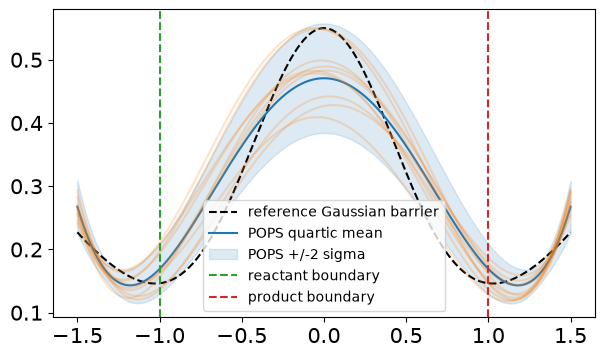

In [ ]:
## Visualization of the fitted potential and uncertainty
x_grid = np.linspace(-1.5, 1.5, 500)
y_pred, y_std, y_min, y_max = pops_model.predict(x_grid[:, None], return_std=True, return_bounds=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_grid, potential_ref.energy(x_grid), "--", color="black", label="reference Gaussian barrier")
ax.plot(x_grid, potential_fit.energy(x_grid), color="tab:blue", label="POPS quartic mean")
for theta in theta_samples_plot:
    ax.plot(x_grid, Polynomial1DPotential(theta).energy(x_grid), color="tab:orange", alpha=0.22)
ax.fill_between(x_grid, y_pred - 2 * y_std, y_pred + 2 * y_std, color="tab:blue", alpha=0.15, label="POPS +/-2 sigma")
ax.axvline(r_boundary, color="tab:green", linestyle="--", label="reactant boundary")
ax.axvline(p_boundary, color="tab:red", linestyle="--", label="product boundary")

ax.legend()
plt.show()

In [ ]:
# parameters for the MD and the AMS simulations
temperature_K = 30000.0
dt = 1.0 * units.fs
friction = 0.01 / units.fs
mass = 1.0

n_rep = 40
n_ams = 20
ini_epsilon = 0.02
max_length_iter = 1_500
workdir = Path("pops_uncertainty_pipeline_1d_run")
clean_run = True


In [17]:
def x_cv(atoms):
    return float(atoms.positions[0, 0])

cv = CollectiveVariables(cv_r=x_cv, cv_p=x_cv, reaction_coordinate=x_cv)
cv.set_r_crit("below")
cv.set_in_r_boundary(float(r_boundary))
cv.set_sigma_r_level(float(r_boundary))
cv.set_out_of_r_zone(float(r_boundary))
cv.set_p_crit("above")
cv.set_in_p_boundary(float(p_boundary))


def make_atoms(potential, x0=0):
    atoms = Atoms("H", positions=[[x0, 0.0, 0.0]], cell=(20.0, 20.0, 20.0))
    atoms.set_masses([mass])
    atoms.calc = OneDimensionalPotentialCalculator(potential)
    return atoms


def make_dyn(atoms, rng, record_noise):
    MaxwellBoltzmannDistribution(atoms, temperature_K=temperature_K, rng=rng)
    return LangevinOBABO(
        atoms,
        timestep=dt,
        temperature_K=temperature_K,
        friction=friction,
        fixcm=False,
        rng=rng,
        record_noise=record_noise,
        logfile=None,
        trajectory=None,
    )


def make_initial_condition(potential):
    atoms = make_atoms(potential, x0=r_boundary + ini_epsilon)
    atoms.info.clear()
    atoms.info["weight_ini_cond"] = 1.0
    return atoms.copy()


def write_initial_conditions(potential, folder, seed0):
    folder.mkdir(parents=True, exist_ok=True)
    atoms = make_initial_condition(potential)
    for i in range(n_rep):
        write(folder / f"ini_{i}.extxyz", atoms, format="extxyz")


def run_ams(potential, run_dir, seed0, record_noise=False):
    if run_dir.exists():
        shutil.rmtree(run_dir)
    run_ini = run_dir / "ini_conds"
    run_ams = run_dir / "ams"
    run_ams.mkdir(parents=True)
    write_initial_conditions(potential, run_ini, seed0)

    atoms = make_atoms(potential, x0=r_boundary + 0.05)
    dyn = make_dyn(atoms, np.random.default_rng(seed0 + 100_000), record_noise=record_noise)
    ams = AMS(
        n_rep=n_rep,
        k_min=1,
        dyn=dyn,
        xi=cv,
        fixcm=False,
        save_all=False,
        rc_threshold=1e-8,
        max_length_iter=max_length_iter,
        verbose=False,
        rng=np.random.default_rng(seed0 + 200_000),
    )
    ams.set_ini_cond_dir(str(run_ini))
    ams.set_ams_dir(str(run_ams), clean=False)
    ams.run()
    return ams, run_ams

In [ ]:
## Run AMS simulations for the MLE parameter.

if clean_run and workdir.exists():
    shutil.rmtree(workdir)

fit_runs = []
for ams_id in range(n_ams):
    ams_fit, ams_fit_dir = run_ams(
        potential_fit,
        workdir / "fit_theta_hat" / f"ams_{ams_id}",
        seed0=10_000 + 1_000 * ams_id,
        record_noise=True,
    )
    fit_runs.append({
        "ams": ams_fit,
        "ams_dir": ams_fit_dir,
        "p": float(ams_fit.p_ams()),
        "success": bool(ams_fit.success),
        "iterations": int(ams_fit.ams_it),
    })
    # print(ams_id, fit_runs[-1]["p"], fit_runs[-1]["success"], fit_runs[-1]["iterations"])

p_fit_probs = np.array([run["p"] for run in fit_runs], dtype=float)
print(f"p(theta_hat) mean={np.mean(p_fit_probs):.6g}, std={np.std(p_fit_probs):.3g}")


p(theta_hat) mean=0.0799673, std=0.027


In [ ]:
# compute scores and FIMs for the AMS runs based on trajectories generated with the MLE potential
rw = Reweightor(
    calculator=OneDimensionalPotentialCalculator(potential_fit),
    mode="linear",
    temperature_K=temperature_K,
    dt=dt,
    friction=friction,
    masses=np.array([mass]),
)

run_scores = []
run_fims = []
run_probs = []

for ams_id, run in enumerate(fit_runs):
    ams_fit = run["ams"]
    ams_fit_dir = run["ams_dir"]
    scores_i = []
    fims_i = []

    for rep_id in range(n_rep):
        traj_file = ams_fit_dir / f"rep_{rep_id}.traj"
        if not traj_file.exists():
            continue
        traj = read(traj_file, index=":")
        if traj and cv.in_p(traj[-1]):
            score, fim = rw.reweight_one_trajectory_linear(traj)
            scores_i.append(np.ravel(score).astype(float))
            fims_i.append(np.asarray(fim, dtype=float))

    if not scores_i:
        print(f"skip MLE AMS {ams_id}: no successful weighted trajectories")
        continue

    run_scores.append(np.array(scores_i, dtype=float))
    run_fims.append(np.array(fims_i, dtype=float))
    run_probs.append(run["p"])
    # print(f"MLE AMS {ams_id}: p={run['p']:.6g}, weighted trajectories={len(scores_i)}")

if not run_scores:
    raise RuntimeError("No successful AMS runs available for reweighting.")

n_rep_reweight = min(arr.shape[0] for arr in run_scores)
scores = np.array([arr[:n_rep_reweight] for arr in run_scores], dtype=float)
fims = np.array([arr[:n_rep_reweight] for arr in run_fims], dtype=float)
model_probs = np.array(run_probs, dtype=float)

print(f"scores shape={scores.shape}, fims shape={fims.shape}, model_probs shape={model_probs.shape}")


scores shape=(20, 40, 5), fims shape=(20, 40, 5, 5), model_probs shape=(20,)


In [ ]:
# run AMS simulations for the reference Gaussian barrier potential 
ref_runs = []
for ams_id in range(n_ams):
    ams_ref, _ = run_ams(
        potential_ref,
        workdir / "direct_gaussian_reference" / f"ams_{ams_id}",
        seed0=90_000 + 1_000 * ams_id,
        record_noise=False,
    )
    ref_runs.append({
        "p": float(ams_ref.p_ams()),
        "success": bool(ams_ref.success),
        "iterations": int(ams_ref.ams_it),
    })
    # print(ams_id, ref_runs[-1]["p"], ref_runs[-1]["success"], ref_runs[-1]["iterations"])

ref_probs = np.array([run["p"] for run in ref_runs], dtype=float)
print(f"p(reference) mean={np.mean(ref_probs):.6g}, std={np.std(ref_probs):.3g}")


p(reference) mean=0.0886814, std=0.0201


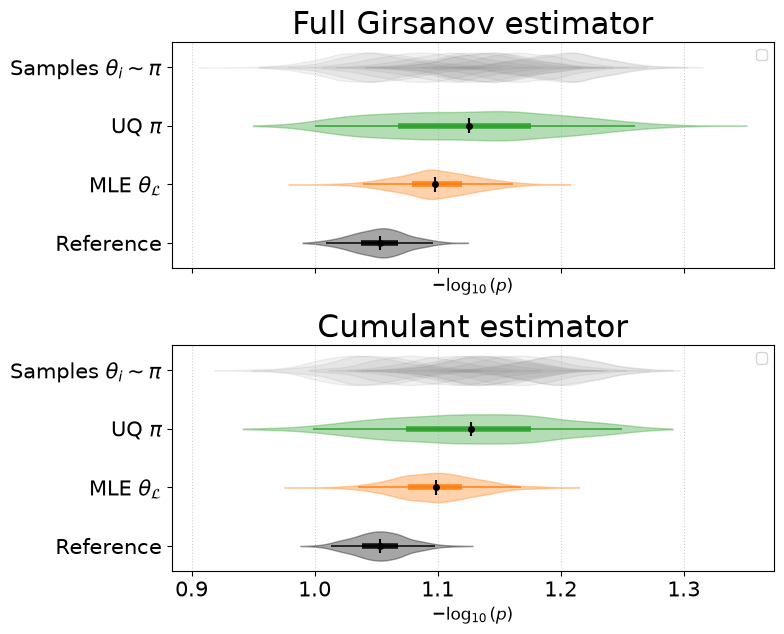

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)
methods = ["full", "loglinear"]
titles = ["Full Girsanov estimator", "Cumulant estimator"]
theta_samples = draw_pops_samples(pops_model, n_samples=5000, theta_hat=theta_hat, seed=123)
delta_theta_samples = (theta_samples - theta_hat).T
for i, (method, title) in enumerate(zip(methods, titles)):
    compute_probability_violin(
        scores,
        model_probs,
        thetas_sample=delta_theta_samples,
        fims=fims,
        ref_probs=ref_probs,
        method=method,
        prior_dist="lognormal",
        variance="estimator",
        ax=axs[i],
        use_Ahat=True,
        n_samples=1000,
        rng=42 + i,
        theta_plot_indices=np.arange(len(theta_samples))[:10],
    )
    axs[i].set_title(title)
    axs[i].legend(loc="best")

fig.tight_layout()
plt.show()
